---
title: Velocity fields
sidebarTitle: Velocity fields
description: Continuous-time vector fields that move particles through space, building from a storm analogy to the geometric foundation of flow matching and diffusion.
tag: "DRAFT"
---

You already have an intuition for velocity fields, even if you have never seen the term. A storm has the same three properties:

- Wind has direction.
- Wind has magnitude.
- Different locations experience different winds.

A storm is, mathematically, a velocity field:

$$
\mathbf{v}(x, y, t)
$$

where the vector at each location $(x, y)$ at time $t$ tells you which way the air is moving and how fast.

## A rotating storm

A simple 2D rotating storm centered at the origin is

$$
\mathbf{v}(x, y) =
\begin{bmatrix} -y \\ x \end{bmatrix}.
$$

This is a pure rotation. Two points pin down the picture:

- At $(1, 0)$: $\mathbf{v} = (0, 1)$, the wind blows upward.
- At $(0, 1)$: $\mathbf{v} = (-1, 0)$, the wind blows to the left.

So the field rotates counterclockwise around the origin.

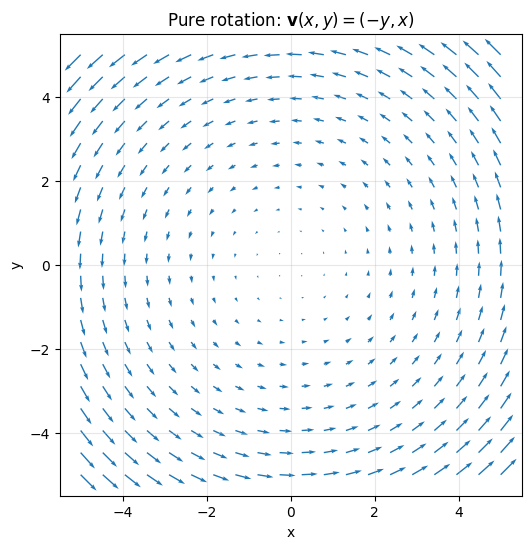

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 20)
y = np.linspace(-5, 5, 20)
X, Y = np.meshgrid(x, y)

U = -Y
V = X

fig, ax = plt.subplots(figsize=(6, 6))
ax.quiver(X, Y, U, V, color="C0")
ax.set_title("Pure rotation: $\\mathbf{v}(x, y) = (-y, x)$")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_aspect("equal")
ax.grid(alpha=0.3)
plt.show()

## Velocity weakens with distance

A real storm is strongest near the eye and weakens outward. A better model is

$$
\mathbf{v}(x, y) =
\frac{1}{x^2 + y^2 + \varepsilon}
\begin{bmatrix} -y \\ x \end{bmatrix},
$$

where $\varepsilon > 0$ avoids the singularity at the origin. Near the center the field is strong; far from the center it decays. The same plotting machinery shows the new structure.

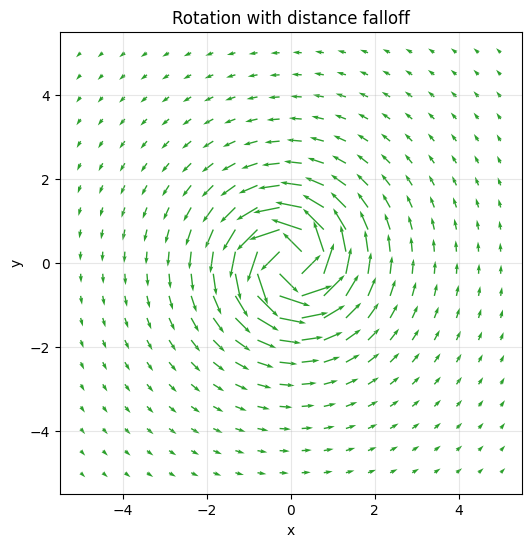

In [2]:
eps = 0.5
norm = X**2 + Y**2 + eps
U = -Y / norm
V = X / norm

fig, ax = plt.subplots(figsize=(6, 6))
ax.quiver(X, Y, U, V, color="C2")
ax.set_title("Rotation with distance falloff")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_aspect("equal")
ax.grid(alpha=0.3)
plt.show()

## Particles in the storm

A velocity field becomes a dynamical system the moment you drop a particle in it. A particle at position $\mathbf{x}(t)$ moves according to

$$
\frac{d \mathbf{x}}{d t} = \mathbf{v}(\mathbf{x}).
$$

You can integrate this numerically. The simplest scheme is the Euler step,

$$
\mathbf{x}(t + \Delta t) = \mathbf{x}(t) + \Delta t \cdot \mathbf{v}(\mathbf{x}(t)),
$$

iterated for many steps. Release many particles at $t = 0$ and follow them: this is what raindrops, leaves, and debris do in a storm.

In [3]:
def storm_v(p, eps=0.5):
    x, y = p[..., 0], p[..., 1]
    norm = x**2 + y**2 + eps
    return np.stack([-y / norm, x / norm], axis=-1)


rng = np.random.default_rng(0)
n_particles = 60
n_steps = 400
dt = 0.05

particles = rng.uniform(-4, 4, size=(n_particles, 2))
trajectories = np.empty((n_steps + 1, n_particles, 2))
trajectories[0] = particles

for step in range(n_steps):
    trajectories[step + 1] = trajectories[step] + dt * storm_v(trajectories[step])

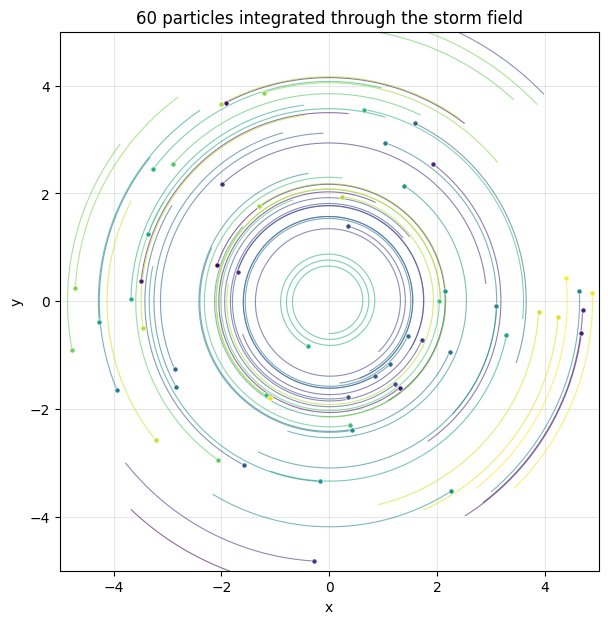

In [4]:
fig, ax = plt.subplots(figsize=(7, 7))
colors = plt.cm.viridis(np.linspace(0, 1, n_particles))
for i in range(n_particles):
    ax.plot(trajectories[:, i, 0], trajectories[:, i, 1],
            color=colors[i], alpha=0.6, lw=0.8)
    ax.scatter(trajectories[-1, i, 0], trajectories[-1, i, 1],
               color=colors[i], s=14, zorder=3, edgecolor="white", linewidth=0.5)
ax.set_title(f"{n_particles} particles integrated through the storm field")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
ax.set_aspect("equal")
ax.grid(alpha=0.3)
plt.show()

## What this teaches

A handful of arrows and one Euler loop already contain every concept you need for the rest of the chapter:

| Concept | What the storm shows |
| --- | --- |
| Vector field | An arrow at every location |
| Velocity field | Arrows describe motion |
| Magnitude | Arrow length |
| Direction | Arrow orientation |
| Spatial dependence | Different locations, different winds |
| Time dependence | Storms evolve, so the field can depend on $t$ |
| Rotation and curl | Circular structure around the eye |
| Singularity | Instability at the center |
| Dynamical system | Particles follow streamlines |

## From a storm to generative AI

The same mathematical object appears in generative modeling:

> **Weather.** $\mathbf{v}(x, y)$ tells air where to move.
>
> **Diffusion and flow matching.** $\mathbf{v}(x, t)$ tells probability mass, or a generated sample, where to move.

In weather you do not get to choose the wind: the atmosphere imposes it. In generative modeling you do choose it. You design a velocity field whose particles, released from Gaussian noise, end up distributed like real data. That is the setup of flow matching, and (as you will see) it is also the deterministic skeleton sitting inside every diffusion model.

The rest of this section makes that statement precise.

## Definition

A time-dependent velocity field is a function

$$
v: \mathbb{R}^d \times [0, 1] \to \mathbb{R}^d,
\qquad (x, t) \mapsto v(x, t)
$$

that assigns a velocity vector $v(x, t) \in \mathbb{R}^d$ to every point $x$ at every time $t$. A particle whose trajectory $x_t \in \mathbb{R}^d$ is driven by this field obeys the ordinary differential equation

$$
\frac{d x_t}{d t} \;=\; v(x_t, t),
\qquad x_0 \sim p_0(x).
$$

Given an initial sample $x_0$ from a source distribution $p_0$ (typically a standard Gaussian), the ODE produces a unique trajectory $\{x_t\}_{t \in [0, 1]}$. The map

$$
\phi_t(x_0) \;=\; x_t
$$

is called the **flow** induced by $v$.

## What the field does to a distribution

The flow does more than move individual particles; it transports the entire source density $p_0$ forward in time. At each $t$, the pushforward

$$
p_t \;=\; (\phi_t)_\sharp \, p_0
$$

is a probability density on $\mathbb{R}^d$ that describes where the swarm of particles is at time $t$. If the velocity field is chosen well, then at $t = 1$ the pushforward matches the data distribution:

$$
p_1 \;\approx\; p_{\text{data}}.
$$

The pair $(v, p_t)$ is linked by the **continuity equation**:

$$
\frac{\partial p_t}{\partial t} + \nabla \cdot \bigl( p_t \, v \bigr) = 0.
$$

This is the same equation that describes mass conservation in a fluid. Read geometrically: the local rate of change of density is determined by the divergence of the mass flux $p_t v$. Designing a velocity field is, in effect, designing a fluid flow that morphs noise into data.

## Generation as trajectory integration

Once you have a learned velocity field $v_\theta$ that approximates a true transport field, sampling from the model amounts to numerical ODE integration. The simplest scheme is **Euler integration** with step size $\Delta t$:

$$
x_{t + \Delta t} \;=\; x_t + \Delta t \cdot v_\theta(x_t, t).
$$

This is the same loop you ran on the storm. Starting from $x_0 \sim \mathcal{N}(0, I)$ and stepping until $t = 1$, you obtain a sample $x_1$ that is approximately distributed according to $p_{\text{data}}$.

Higher-order solvers (Heun, RK4, adaptive Dormand-Prince) integrate the same field with fewer steps and lower truncation error. The choice of solver is decoupled from the choice of velocity field, which is a practical advantage of the flow-matching formulation.

## Three views of the same object

Each figure above showed one face of the velocity field:

1. **Vector field view.** At each $(x, t)$, draw the arrow $v(x, t)$. The quiver plots are this view.
2. **Streamline view.** Fix $t$ and trace integral curves of $v(\cdot, t)$.
3. **Particle view.** Release a cloud of particles at $t = 0$ and follow them as they advect under $v$. The trajectory plot is this view.

The same machinery underlies fluid mechanics, dynamical systems, and the optical-flow problem in computer vision. Flow matching borrows the geometry and applies it to generative modeling: the model learns how probability mass flows through space and time.

## What gets learned

The network is not asked to denoise or to predict a discrete sequence of tokens. It is asked to regress one scalar-valued function per output dimension:

$$
v_\theta(x, t) \;\approx\; v^\star(x, t)
$$

where $v^\star$ is a target velocity field induced by a chosen probability path between $p_0$ and $p_{\text{data}}$. The next page introduces probability paths and shows how the regression target is constructed.

## Further reading

- Lipman et al. (2024). [Flow Matching Guide and Code](https://arxiv.org/abs/2412.06264), Sections 2-3 cover velocity fields and the continuity equation in detail.
- Lipman et al. (2023). [Flow Matching for Generative Modeling](https://arxiv.org/abs/2210.02747), the foundational paper.